In [1]:
from pathlib import Path
import numpy as np
import torch
from typing import List
from torch.nn.utils.rnn import pad_sequence
from mltrainer import rnn_models, Trainer
from torch import optim

from mads_datasets import datatools
import mltrainer
mltrainer.__version__

'0.2.5'

# 1 Iterators
We will be using an interesting dataset. [link](https://tev.fbk.eu/resources/smartwatch)

From the site:
> The SmartWatch Gestures Dataset has been collected to evaluate several gesture recognition algorithms for interacting with mobile applications using arm gestures. Eight different users performed twenty repetitions of twenty different gestures, for a total of 3200 sequences. Each sequence contains acceleration data from the 3-axis accelerometer of a first generation Sony SmartWatch™, as well as timestamps from the different clock sources available on an Android device. The smartwatch was worn on the user's right wrist. 


In [2]:
import shutil
from copy import deepcopy
from typing import Any, Mapping

from mads_datasets.base import AbstractDatasetFactory, DatasetProtocol
from mads_datasets.datasets import TSDataset
from mads_datasets.datatools import keep_subdirs_only, walk_dir
from mads_datasets.settings import DatasetSettings


class CorrectGesturesFactory(AbstractDatasetFactory[DatasetSettings]):
    """
    Leave-one-user-out split: holdout_user -> valid, rest -> train.
    """

    def __init__(self, settings: DatasetSettings, **kwargs: Any) -> None:
        super().__init__(settings, **kwargs)
        self._created = False
        self.datasets: Mapping[str, DatasetProtocol] = {}

    def create_dataset(self, *args: Any, **kwargs: Any) -> Mapping[str, DatasetProtocol]:
        self.download_data()

        if self._created:
            return deepcopy(self.datasets)

        holdout_user: str = kwargs.pop("holdout_user", "U01")

        formats = [f.value for f in self._settings.formats]
        datadir = self.subfolder / "gestures-dataset"

        img = datadir / "gestures.png"
        if img.exists():
            shutil.move(img, datadir.parent / "gestures.png")
        keep_subdirs_only(datadir)

        paths = [p for p in walk_dir(datadir) if p.suffix in formats]

        trainpaths = [p for p in paths if p.parts[-3] != holdout_user]
        validpaths = [p for p in paths if p.parts[-3] == holdout_user]

        if not validpaths:
            available = sorted({p.parts[-3] for p in paths})
            raise ValueError(
                f"No files found for user '{holdout_user}'. Available users: {available}"
            )

        train_users = {p.parts[-3] for p in trainpaths}
        valid_users = {p.parts[-3] for p in validpaths}
        assert train_users.isdisjoint(valid_users), "LEAK: users appear in both splits!"

        print(f"Train users: {sorted(train_users)}")
        print(f"Valid users: {sorted(valid_users)}")

        traindataset = TSDataset(trainpaths)
        validdataset = TSDataset(validpaths)

        datasets = {"train": traindataset, "valid": validdataset}
        self.datasets = datasets
        self._created = True
        return datasets

In [60]:
from mads_datasets.settings import gesturesdatasetsettings
from pathlib import Path
from mltrainer.preprocessors import PaddedPreprocessor
preprocessor = PaddedPreprocessor()
datadir = Path.home() / ".cache/mads_datasets/gestures"

# Holdout users
holdout_users = ["U01", "U03", "U06"]

splits = {}  

for holdout_user in holdout_users:
    print("\n" + "=" * 60)
    print(f"Creating split for holdout_user={holdout_user}")
    print("=" * 60)

    factory = CorrectGesturesFactory(gesturesdatasetsettings, datadir=datadir)

    datasets = factory.create_dataset(holdout_user=holdout_user)

    streamers = factory.create_datastreamer(batchsize=32, preprocessor=preprocessor)

    train = streamers["train"]
    valid = streamers["valid"]

    # (optioneel) log even de steps die je later in TrainerSettings stopt
    print(f"train_steps = {len(train)}")
    print(f"valid_steps = {len(valid)}")

    # sla op zodat je training later in dezelfde loop kan draaien
    splits[holdout_user] = {
        "factory": factory,
        "datasets": datasets,
        "streamers": streamers,
        "train": train,
        "valid": valid,
    }

# User kiezen
train = splits["U06"]["train"]
valid = splits["U06"]["valid"]

2026-03-07 19:21:46.522 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /home/jgerrits/.cache/mads_datasets/gestures/gestures



Creating split for holdout_user=U01
Train users: ['U02', 'U03', 'U04', 'U05', 'U06', 'U07', 'U08']
Valid users: ['U01']


100%|██████████| 401/401 [00:00<00:00, 4284.28it/s]
2026-03-07 19:21:47.525 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /home/jgerrits/.cache/mads_datasets/gestures/gestures
2026-03-07 19:21:47.750 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /home/jgerrits/.cache/mads_datasets/gestures/gestures


train_steps = 89
valid_steps = 12

Creating split for holdout_user=U03
Train users: ['U01', 'U02', 'U04', 'U05', 'U06', 'U07', 'U08']
Valid users: ['U03']


100%|██████████| 429/429 [00:00<00:00, 4378.13it/s]
2026-03-07 19:21:48.733 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /home/jgerrits/.cache/mads_datasets/gestures/gestures
2026-03-07 19:21:48.959 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /home/jgerrits/.cache/mads_datasets/gestures/gestures


train_steps = 88
valid_steps = 13

Creating split for holdout_user=U06
Train users: ['U01', 'U02', 'U03', 'U04', 'U05', 'U07', 'U08']
Valid users: ['U06']


100%|██████████| 401/401 [00:00<00:00, 4180.88it/s]
2026-03-07 19:21:49.938 | INFO     | mads_datasets.base:download_data:121 - Folder already exists at /home/jgerrits/.cache/mads_datasets/gestures/gestures


train_steps = 89
valid_steps = 12


In [61]:
import inspect
print(inspect.signature(factory.create_datastreamer))

(batchsize: int, **kwargs) -> Mapping[str, mads_datasets.base.DatastreamerProtocol]


In [62]:
len(train), len(valid)

(89, 12)

In [63]:
trainstreamer = train.stream()
validstreamer = valid.stream()
x, y = next(iter(trainstreamer))
x.shape, y

(torch.Size([32, 33, 3]),
 tensor([ 9,  8, 12,  5,  6, 15,  7,  9, 14, 15,  5,  7,  5, 12,  6, 15,  8,  6,
          8, 19, 15, 15,  9,  8,  7,  5,  6,  5,  3, 10,  6,  9]))

Can you make sense of the shape?
What does it mean that the shapes are sometimes (32, 27, 3), but a second time might look like (32, 30, 3)? In other words, the second (or first, if you insist on starting at 0) dimension changes. Why is that? How does the model handle this? Do you think this is already padded, or still has to be padded?


Answer: The shape of the data is batch size (32), timestamps (26) and features per timestamp (3).
The difference between 26 and 30 is the different amount of timesteps for different gestures.
The tensor consists of all the output classes (32 outputs), what makes this a sequence-to-one classification problem.

I think the model can handle the different amount of timesteps, because it is a recurrent process. In the final steps of the network, the number of outputs is brought back to the needed number of 20 outputs. 

Discussed with Sam in class: We don't see how the data is padded up to now?

Update after data exploration: Data looks to be padded a lot. (see below)

## Extra run of data exploration after iteration 2

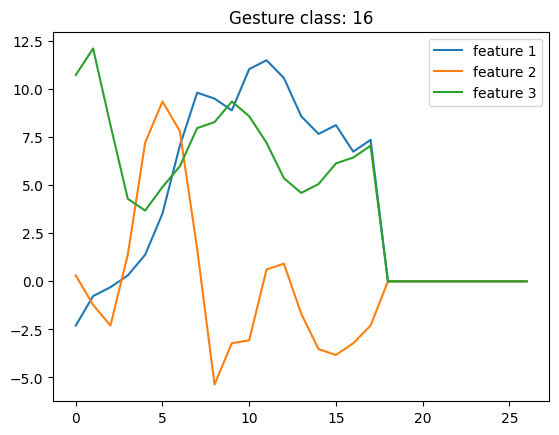

In [64]:
import matplotlib.pyplot as plt

x, y = next(iter(trainstreamer))

sample = x[0]  
label = y[0]

plt.plot(sample[:,0], label="feature 1")
plt.plot(sample[:,1], label="feature 2")
plt.plot(sample[:,2], label="feature 3")
plt.legend()
plt.title(f"Gesture class: {label}")
plt.show()

In [65]:
print(sample)

tensor([[-2.2984,  0.3065, 10.7260],
        [-0.7661, -1.2258, 12.1051],
        [-0.3065, -2.2984,  8.1211],
        [ 0.3065,  1.3791,  4.2904],
        [ 1.3791,  7.2018,  3.6775],
        [ 3.5243,  9.3470,  4.9033],
        [ 7.0485,  7.8147,  5.9759],
        [ 9.8067,  1.6855,  7.9679],
        [ 9.5002, -5.3630,  8.2744],
        [ 8.8873, -3.2178,  9.3470],
        [11.0325, -3.0646,  8.5808],
        [11.4922,  0.6129,  7.2018],
        [10.5728,  0.9194,  5.3630],
        [ 8.5808, -1.6855,  4.5969],
        [ 7.6614, -3.5243,  5.0566],
        [ 8.1211, -3.8307,  6.1292],
        [ 6.7421, -3.2178,  6.4356],
        [ 7.3550, -2.2984,  7.0485],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000]])


# 2 Excercises
Lets test a basemodel, and try to improve upon that.

Fill the gestures.gin file with relevant settings for `input_size`, `hidden_size`, `num_layers` and `horizon` (which, in our case, will be the number of classes...)

As a rule of thumbs: start lower than you expect to need!

In [66]:
from mltrainer import TrainerSettings, ReportTypes
from mltrainer.metrics import Accuracy

accuracy = Accuracy()


In [67]:
model = rnn_models.BaseRNN(
    input_size=3,
    hidden_size=64,
    num_layers=1,
    horizon=20,
)

Test the model. What is the output shape you need? Remember, we are doing classification!

In [68]:
yhat = model(x)
yhat.shape

torch.Size([32, 20])

Test the accuracy

In [69]:
accuracy(y, yhat)

0.0625

What do you think of the accuracy? What would you expect from blind guessing?

Check shape of `y` and `yhat`

In [70]:
yhat.shape, y.shape

(torch.Size([32, 20]), torch.Size([32]))

And look at the output of yhat

In [71]:
yhat[0]

tensor([ 0.0165, -0.0946,  0.0820,  0.0392,  0.0419,  0.1382, -0.0253,  0.0058,
         0.0580, -0.0280,  0.0419,  0.0222, -0.0359,  0.0579, -0.0274,  0.0908,
         0.1224, -0.0164, -0.0196,  0.0403], grad_fn=<SelectBackward0>)

Does this make sense to you? If you are unclear, go back to the classification problem with the MNIST, where we had 10 classes.

We have a classification problem, so we need Cross Entropy Loss.
Remember, [this has a softmax built in](https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html) 

In [72]:
loss_fn = torch.nn.CrossEntropyLoss()
loss = loss_fn(yhat, y)
loss

tensor(2.9900, grad_fn=<NllLossBackward0>)

In [73]:
import torch
if torch.backends.mps.is_available() and torch.backends.mps.is_built():
    device = torch.device("mps")
    print("Using MPS")
elif torch.cuda.is_available():
    device = "cuda:0"
    print("using cuda")
else:
    device = "cpu"
    print("using cpu")

# on my mac, at least for the BaseRNN model, mps does not speed up training
# probably because the overhead of copying the data to the GPU is too high
# so i override the device to cpu
device = "cpu"
# however, it might speed up training for larger models, with more parameters

using cpu


Set up the settings for the trainer and the different types of logging you want

In [74]:
import mlflow
from datetime import datetime

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("gestures")
modeldir = Path("gestures").resolve()
if not modeldir.exists():
    modeldir.mkdir(parents=True)


In [75]:
print("MLflow tracking URI:", mlflow.get_tracking_uri())

MLflow tracking URI: sqlite:///mlflow.db


# Loop starts here

In [76]:
settings = TrainerSettings(
    epochs=25, # increase this to about 100 for training
    metrics=[accuracy],
    logdir=Path("gestures"),
    train_steps=len(train),
    valid_steps=len(valid),
    reporttypes=[ReportTypes.TOML, ReportTypes.TENSORBOARD, ReportTypes.MLFLOW],
    scheduler_kwargs={"factor": 0.5, "patience": 5},
    earlystop_kwargs = {
        "save": False, # save every best model, and restore the best one
        "verbose": True,
        "patience": 5, # number of epochs with no improvement after which training will be stopped
        "delta": 0.0, # minimum change to be considered an improvement
    }
)
settings

epochs: 25
metrics: [Accuracy]
logdir: gestures
train_steps: 89
valid_steps: 12
reporttypes: [<ReportTypes.TOML: 'TOML'>, <ReportTypes.TENSORBOARD: 'TENSORBOARD'>, <ReportTypes.MLFLOW: 'MLFLOW'>]
optimizer_kwargs: {'lr': 0.001, 'weight_decay': 1e-05}
scheduler_kwargs: {'factor': 0.5, 'patience': 5}
earlystop_kwargs: {'save': False, 'verbose': True, 'patience': 5, 'delta': 0.0}

In [77]:
import torch.nn as nn
import torch
from torch import Tensor
from dataclasses import dataclass

@dataclass
class ModelConfig:
    input_size: int
    hidden_size: int
    num_layers: int
    output_size: int
    dropout: float = 0.0

    conv_channels: int = 32     # aantal filters
    conv_kernel: int = 3        # kernel size 
    use_pool: bool = False      # eventueel sequence verkorten
    pool_kernel: int = 2

class ConvGRUmodel(nn.Module):  
    def __init__(self, config) -> None:
        super().__init__()
        self.config = config

        
        padding = config.conv_kernel // 2  # houdt lengte ongeveer gelijk bij odd kernel

        self.conv = nn.Conv1d(
            in_channels=config.input_size,      # = F (3)
            out_channels=config.conv_channels,   # = C_out
            kernel_size=config.conv_kernel,
            padding=padding,
        )
        self.act = nn.ReLU()

        self.pool = None
        if config.use_pool:
            self.pool = nn.MaxPool1d(kernel_size=config.pool_kernel)

        # GRU input_size moet nu conv_channels zijn
        self.rnn = nn.GRU(
            input_size=config.conv_channels,     #
            hidden_size=config.hidden_size,
            dropout=config.dropout,
            batch_first=True,
            num_layers=config.num_layers,
        )

        self.linear = nn.Linear(config.hidden_size, config.output_size)

    def forward(self, x: Tensor) -> Tensor:
        # x: (B, T, F)
        x = x.permute(0, 2, 1)       # (B, F, T) voor Conv1D

        x = self.conv(x)             #  (B, C_out, T_out)
        x = self.act(x)

        if self.pool is not None:
            x = self.pool(x)         # (B, C_out, T_out/2) bij kernel=2

        x = x.permute(0, 2, 1)       # (B, T_out, C_out) voor GRU

        x, _ = self.rnn(x)           # -> (B, T_out, hidden_size)
        last_step = x[:, -1, :]      # -> (B, hidden_size)
        yhat = self.linear(last_step)
        return yhat

In [78]:
config = ModelConfig(
    input_size=3,
    hidden_size=64,
    num_layers=2,
    output_size=20,
    dropout=0.2,
    #nieuw
    conv_channels=32,
    conv_kernel=5,
    use_pool=True,
    pool_kernel=2,
)

model_type = "U03-ConvGRU"

run_name = (
    f"{model_type}_"
    f"c{config.conv_channels}_"
    f"k{config.conv_kernel}_"
    f"pool{int(config.use_pool)}_"
    f"h{config.hidden_size}_"
    f"l{config.num_layers}_"
    f"do{config.dropout}_"
    f"ep{settings.epochs}"
)

with mlflow.start_run(run_name=run_name):

    mlflow.set_tag("model_type", model_type)
    mlflow.set_tag("developer", "UserU03")

    mlflow.log_params({
        "input_size": config.input_size,
        "conv_channels": config.conv_channels,   
        "conv_kernel": config.conv_kernel,       
        "use_pool": config.use_pool,             
        "pool_kernel": config.pool_kernel,       

        "hidden_size": config.hidden_size,
        "num_layers": config.num_layers,
        "dropout": config.dropout,
        "output_size": config.output_size,
        "epochs": settings.epochs,
        "batchsize": 32,
        "optimizer": "Adam",
    })

    # ConvGRUmodel gebruiken
    model = ConvGRUmodel(config=config)

    trainer = Trainer(
        model=model,
        settings=settings,
        loss_fn=loss_fn,
        optimizer=optim.Adam,
        traindataloader=trainstreamer,
        validdataloader=validstreamer,
        scheduler=optim.lr_scheduler.ReduceLROnPlateau,
        device=device,
    )

    trainer.loop()

    if not settings.earlystop_kwargs["save"]:
        tag = datetime.now().strftime("%Y%m%d-%H%M-")
        modelpath = modeldir / (tag + "model.pt")
        torch.save(model, modelpath)

2026-03-07 19:21:50.762 | INFO     | mltrainer.trainer:dir_add_timestamp:24 - Logging to gestures/20260307-192150
2026-03-07 19:21:50.763 | INFO     | mltrainer.trainer:__init__:68 - Found earlystop_kwargs in settings.Set to None if you dont want earlystopping.
100%|██████████| 89/89 [00:01<00:00, 45.51it/s]
2026-03-07 19:21:52.838 | INFO     | mltrainer.trainer:report:209 - Epoch 0 train 2.5416 test 2.0840 metric ['0.2891']
100%|██████████| 89/89 [00:01<00:00, 72.33it/s]
2026-03-07 19:21:54.182 | INFO     | mltrainer.trainer:report:209 - Epoch 1 train 1.8992 test 1.4381 metric ['0.4349']
100%|██████████| 89/89 [00:01<00:00, 68.63it/s]
2026-03-07 19:21:55.592 | INFO     | mltrainer.trainer:report:209 - Epoch 2 train 1.3396 test 1.1066 metric ['0.5234']
100%|██████████| 89/89 [00:01<00:00, 67.50it/s]
2026-03-07 19:21:57.030 | INFO     | mltrainer.trainer:report:209 - Epoch 3 train 0.9913 test 0.8061 metric ['0.6927']
100%|██████████| 89/89 [00:01<00:00, 72.12it/s]
2026-03-07 19:21:58.37

Try to update the code above by changing the hyperparameters.
    
To discern between the changes, also modify the tag mlflow.set_tag("model", "new-tag-here") where you add
a new tag of your choice. This way you can keep the models apart.

In [79]:
from pathlib import Path
print(Path("mlflow.db").resolve())

/home/jgerrits/portfolio-S3/3-hypertuning-rnn/mlflow.db


cd /home/jgerrits/portfolio-S3/3-hypertuning-rnn


mlflow ui --backend-store-uri sqlite:///mlflow.db


In [80]:
#trainer.loop() # if you want to pick up training, loop will continue from the last epoch

In [81]:
#mlflow.end_run()